# Health Data — Glucose + Oura Visualization

This notebook loads the merged dataset from `pipeline.py` and visualizes:
- CGM glucose time-series
- Daily glucose statistics (mean, TIR, GMI)
- Oura daily readiness, sleep, and activity scores (if token is available)
- Correlation between glucose and Oura metrics

> **Setup**: run `python do_auth.py` once from the project root to get the Oura token.  
> LibreLink visualizations work without the token.

In [1]:
import sys
sys.path.insert(0, '..')  # project root

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import libre_client
import pipeline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 4)
print('Imports OK')

Imports OK


## 1. Load Data

In [2]:
# Load raw CGM readings and daily glucose stats
glucose, daily = pipeline.load_glucose_only(data_dir='../libre_data')

print(f'CGM readings : {len(glucose):,}')
print(f'Days covered : {len(daily)}')
print(f'Date range   : {glucose["timestamp"].min().date()} to {glucose["timestamp"].max().date()}')
daily.head()

CGM readings : 192,225
Days covered : 1364
Date range   : 2022-06-13 to 2026-03-14


,date,glucose_mean,glucose_std,glucose_min,glucose_max,glucose_readings,glucose_tir,glucose_cv,glucose_gmi
0,2022-06-13,155.44,46.04,83.0,271.0,88,0.727,0.296,7.03
1,2022-06-14,152.23,44.86,95.0,270.0,84,0.786,0.295,6.95
2,2022-06-15,127.22,55.40,40.0,248.0,73,0.671,0.435,6.35
3,2022-06-16,155.01,45.42,84.0,226.0,83,0.651,0.293,7.02
4,2022-06-17,138.15,41.86,83.0,233.0,94,0.798,0.303,6.61


In [3]:
# Try to build merged dataset with Oura data
# Falls back to glucose-only if token is missing
try:
    merged = pipeline.build_daily_dataset("2025-12-01", "2026-03-13", data_dir='../libre_data')
    oura_cols = [c for c in merged.columns if c.startswith(('sleep_', 'readiness_', 'activity_', 'stress_', 'spo2_'))]
    has_oura = bool(oura_cols)
    print(f'Merged dataset: {len(merged)} rows, {len(merged.columns)} columns')
    if has_oura:
        print(f'Oura columns  : {oura_cols[:8]}...')
    else:
        print('No Oura data — run do_auth.py to enable Oura metrics')
except Exception as e:
    print(f'Oura unavailable: {e}')
    merged = daily.copy()
    has_oura = False

Merged dataset: 96 rows, 65 columns
Oura columns  : ['sleep_score', 'sleep_timestamp', 'sleep_contributors.deep_sleep', 'sleep_contributors.efficiency', 'sleep_contributors.latency', 'sleep_contributors.rem_sleep', 'sleep_contributors.restfulness', 'sleep_contributors.timing']...


## 2. CGM Glucose Time-Series

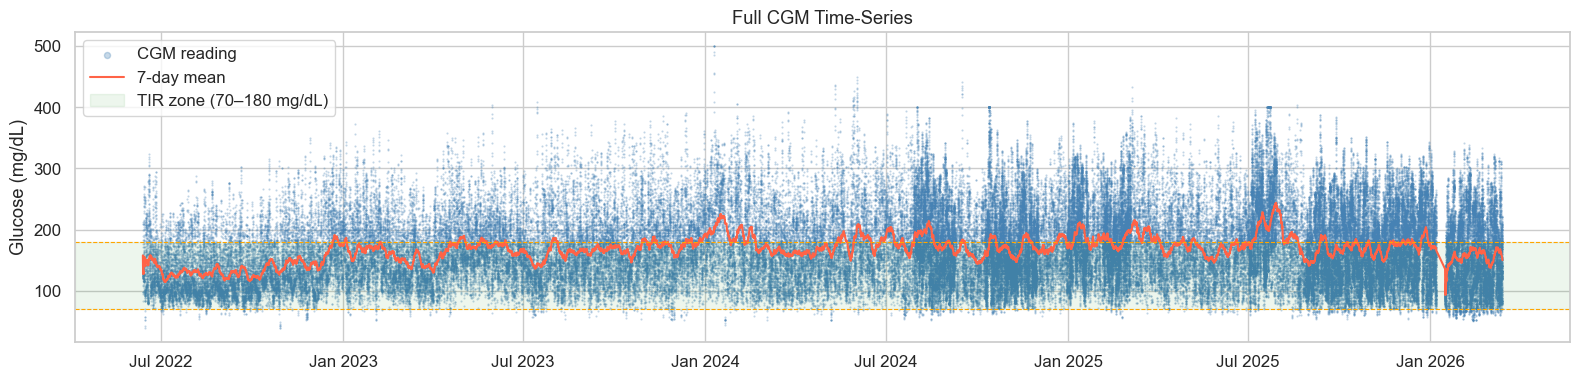

In [4]:
# Full time-series (all years) — 7-day rolling mean
g = glucose.set_index('timestamp').sort_index()
rolling_mean = g['glucose_mgdl'].rolling('7D').mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.scatter(g.index, g['glucose_mgdl'], s=0.3, alpha=0.3, color='steelblue', label='CGM reading')
ax.plot(rolling_mean.index, rolling_mean.values, color='tomato', lw=1.5, label='7-day mean')
ax.axhspan(70, 180, color='green', alpha=0.07, label='TIR zone (70–180 mg/dL)')
ax.axhline(70,  color='orange', lw=0.8, ls='--')
ax.axhline(180, color='orange', lw=0.8, ls='--')
ax.set_title('Full CGM Time-Series')
ax.set_ylabel('Glucose (mg/dL)')
ax.legend(markerscale=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

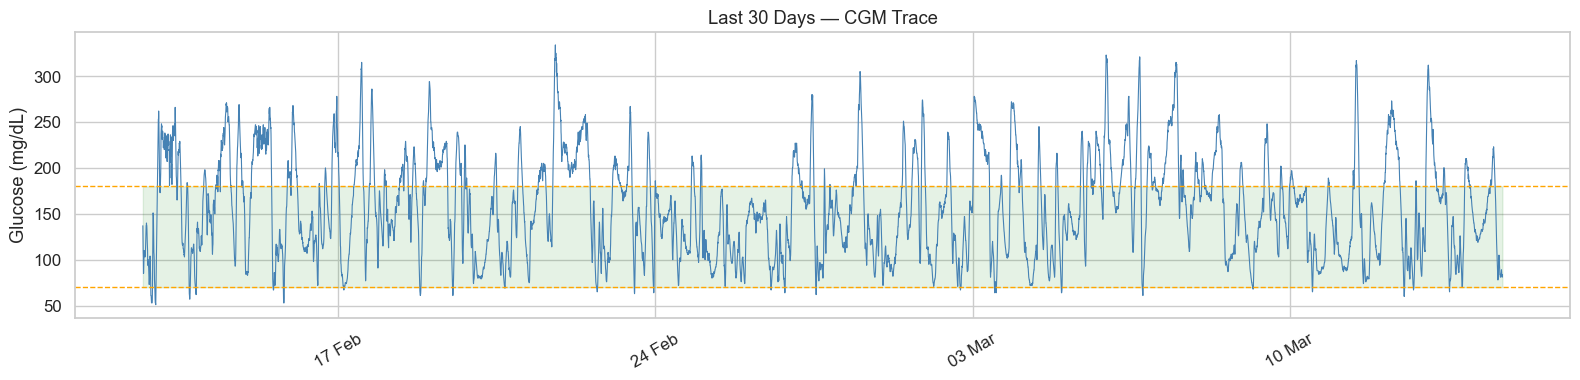

In [5]:
# Last 30 days detail
last30 = g.last('30D')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(last30.index, last30['glucose_mgdl'], lw=0.8, color='steelblue')
ax.fill_between(last30.index, 70, 180, alpha=0.1, color='green', label='TIR zone')
ax.axhline(70,  color='orange', lw=1, ls='--')
ax.axhline(180, color='orange', lw=1, ls='--')
ax.set_title('Last 30 Days — CGM Trace')
ax.set_ylabel('Glucose (mg/dL)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3. Daily Glucose Statistics

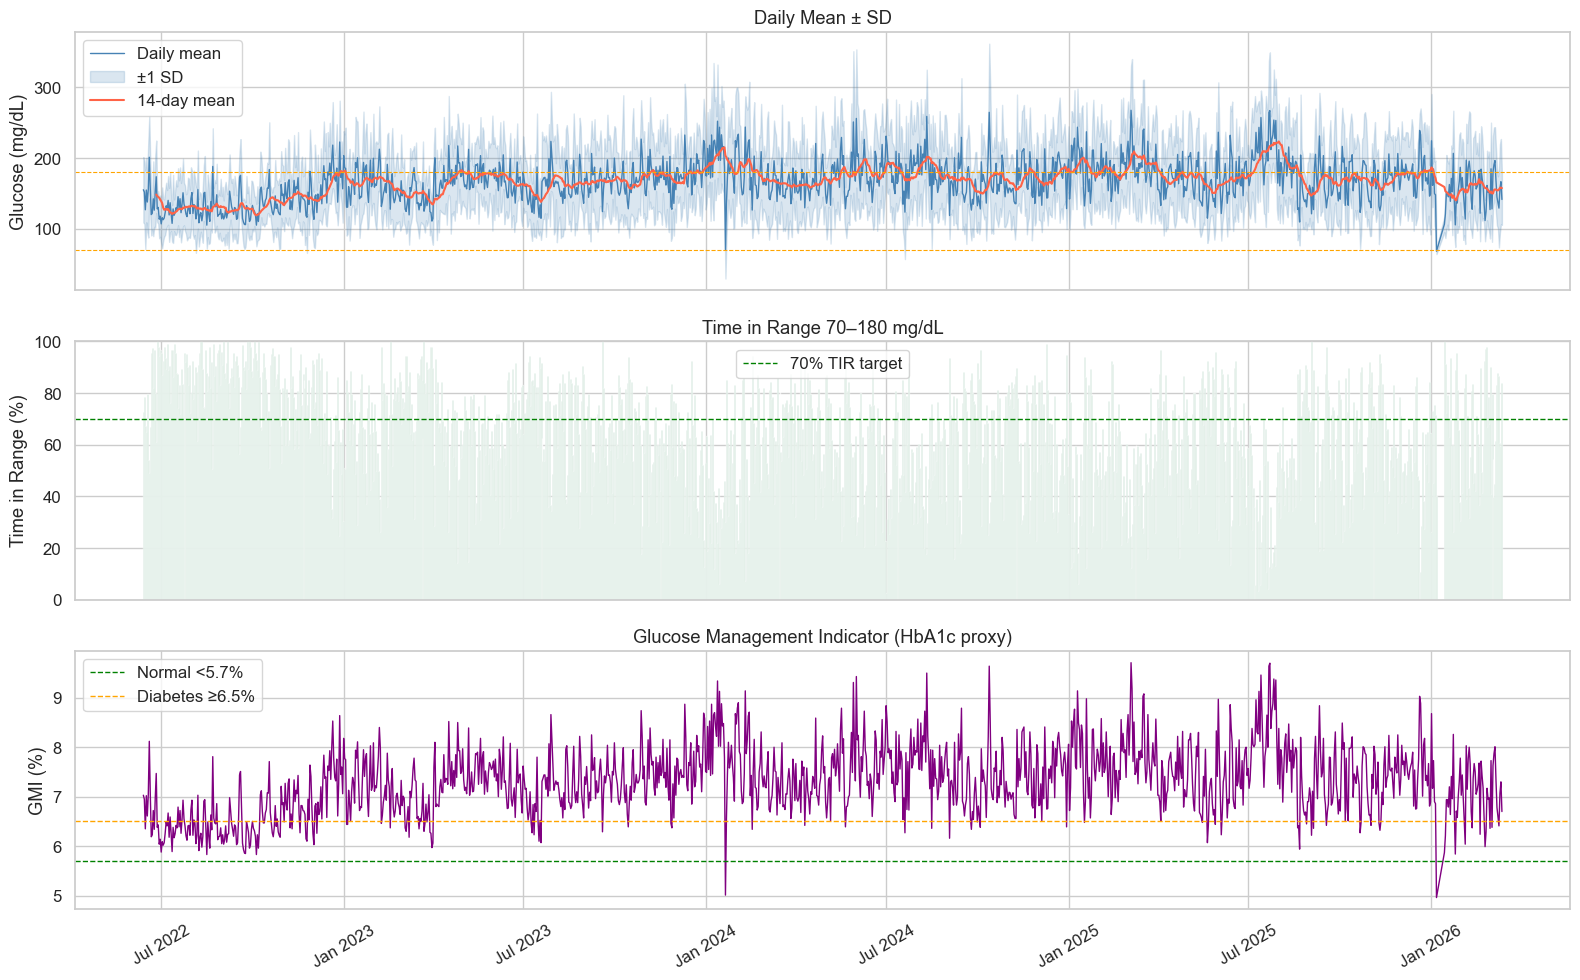

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

d = daily.set_index('date').sort_index()
roll = d.rolling(14)  # 14-day rolling

# Mean glucose + std band
ax = axes[0]
ax.plot(d.index, d['glucose_mean'], color='steelblue', lw=1, label='Daily mean')
ax.fill_between(d.index,
                d['glucose_mean'] - d['glucose_std'],
                d['glucose_mean'] + d['glucose_std'],
                alpha=0.2, color='steelblue', label='±1 SD')
ax.plot(roll['glucose_mean'].mean().index, roll['glucose_mean'].mean().values,
        color='tomato', lw=1.5, label='14-day mean')
ax.axhline(180, color='orange', ls='--', lw=0.8)
ax.axhline(70,  color='orange', ls='--', lw=0.8)
ax.set_ylabel('Glucose (mg/dL)')
ax.set_title('Daily Mean ± SD')
ax.legend()

# Time in range
ax = axes[1]
ax.bar(d.index, d['glucose_tir'] * 100, width=1, color='seagreen', alpha=0.7)
ax.axhline(70, color='green', ls='--', lw=1, label='70% TIR target')
ax.set_ylabel('Time in Range (%)')
ax.set_title('Time in Range 70–180 mg/dL')
ax.set_ylim(0, 100)
ax.legend()

# GMI (HbA1c proxy)
ax = axes[2]
ax.plot(d.index, d['glucose_gmi'], color='purple', lw=1)
ax.axhline(5.7, color='green',  ls='--', lw=1, label='Normal <5.7%')
ax.axhline(6.5, color='orange', ls='--', lw=1, label='Diabetes ≥6.5%')
ax.set_ylabel('GMI (%)')
ax.set_title('Glucose Management Indicator (HbA1c proxy)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 4. Oura vs Glucose (requires Oura token)

In [7]:
if not has_oura:
    print('Oura data not available. Run do_auth.py then re-run cells 2 & 4.')
else:
    m = merged.set_index('date').sort_index().dropna(subset=['glucose_mean'])

    oura_scores = [c for c in m.columns if c.endswith('_score')]
    print(f'Oura score columns: {oura_scores}')
    m[['glucose_mean'] + oura_scores].tail()

Oura score columns: ['sleep_score', 'readiness_score', 'activity_score']


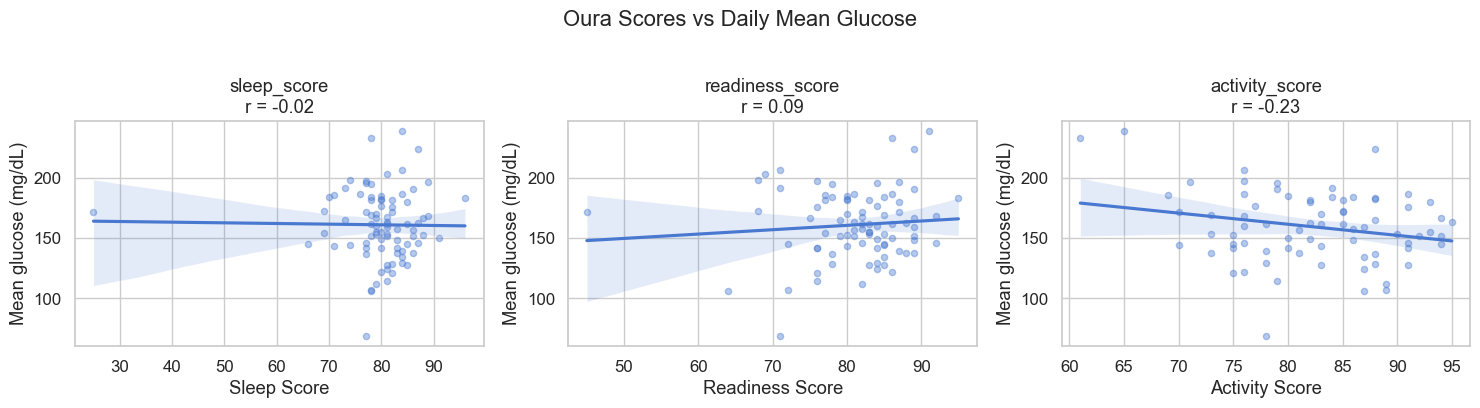

In [8]:
if has_oura:
    m = merged.set_index('date').sort_index()
    oura_scores = [c for c in m.columns if c.endswith('_score')]

    n = len(oura_scores)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, oura_scores):
        subset = m[['glucose_mean', col]].dropna()
        sns.regplot(data=subset, x=col, y='glucose_mean', ax=ax,
                    scatter_kws={'alpha': 0.4, 's': 20})
        corr = subset.corr().iloc[0, 1]
        ax.set_title(f'{col}\nr = {corr:.2f}')
        ax.set_xlabel(col.replace('_', ' ').title())
        ax.set_ylabel('Mean glucose (mg/dL)')

    plt.suptitle('Oura Scores vs Daily Mean Glucose', y=1.02)
    plt.tight_layout()
    plt.show()

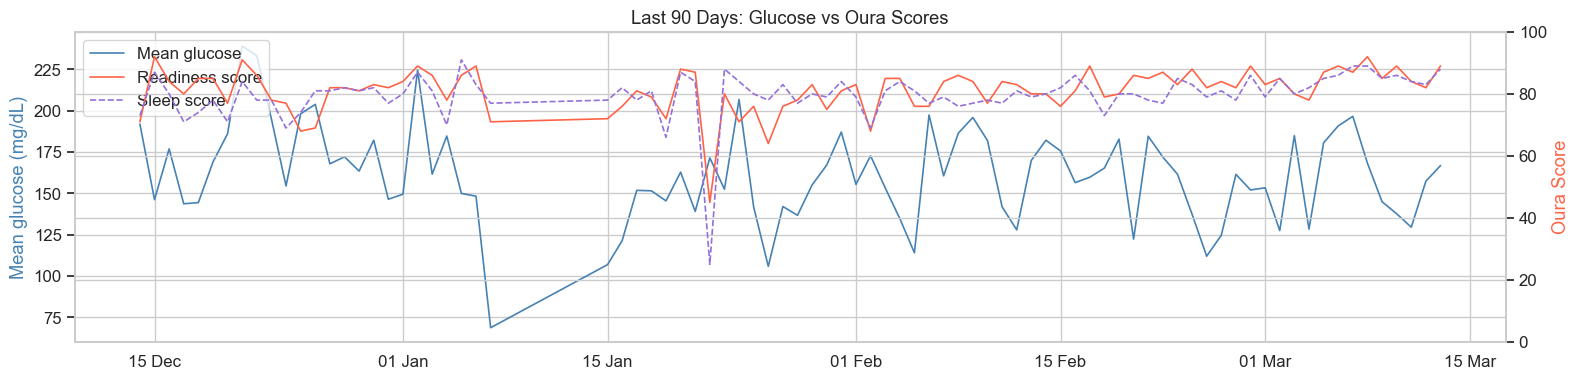

In [9]:
if has_oura:
    # Dual-axis: glucose mean and readiness score over last 90 days
    m = merged.set_index('date').sort_index().last('90D')
    readiness_col = next((c for c in m.columns if 'readiness' in c and 'score' in c), None)
    sleep_col     = next((c for c in m.columns if 'sleep' in c    and 'score' in c), None)

    if readiness_col or sleep_col:
        fig, ax1 = plt.subplots(figsize=(16, 4))
        ax2 = ax1.twinx()

        ax1.plot(m.index, m['glucose_mean'], color='steelblue', lw=1.2, label='Mean glucose')
        ax1.set_ylabel('Mean glucose (mg/dL)', color='steelblue')

        if readiness_col:
            ax2.plot(m.index, m[readiness_col], color='tomato', lw=1.2, label='Readiness score')
        if sleep_col:
            ax2.plot(m.index, m[sleep_col], color='mediumpurple', lw=1.2, ls='--', label='Sleep score')
        ax2.set_ylabel('Oura Score', color='tomato')
        ax2.set_ylim(0, 100)

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        ax1.set_title('Last 90 Days: Glucose vs Oura Scores')
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

## 5. Correlation Heatmap (Oura + Glucose)

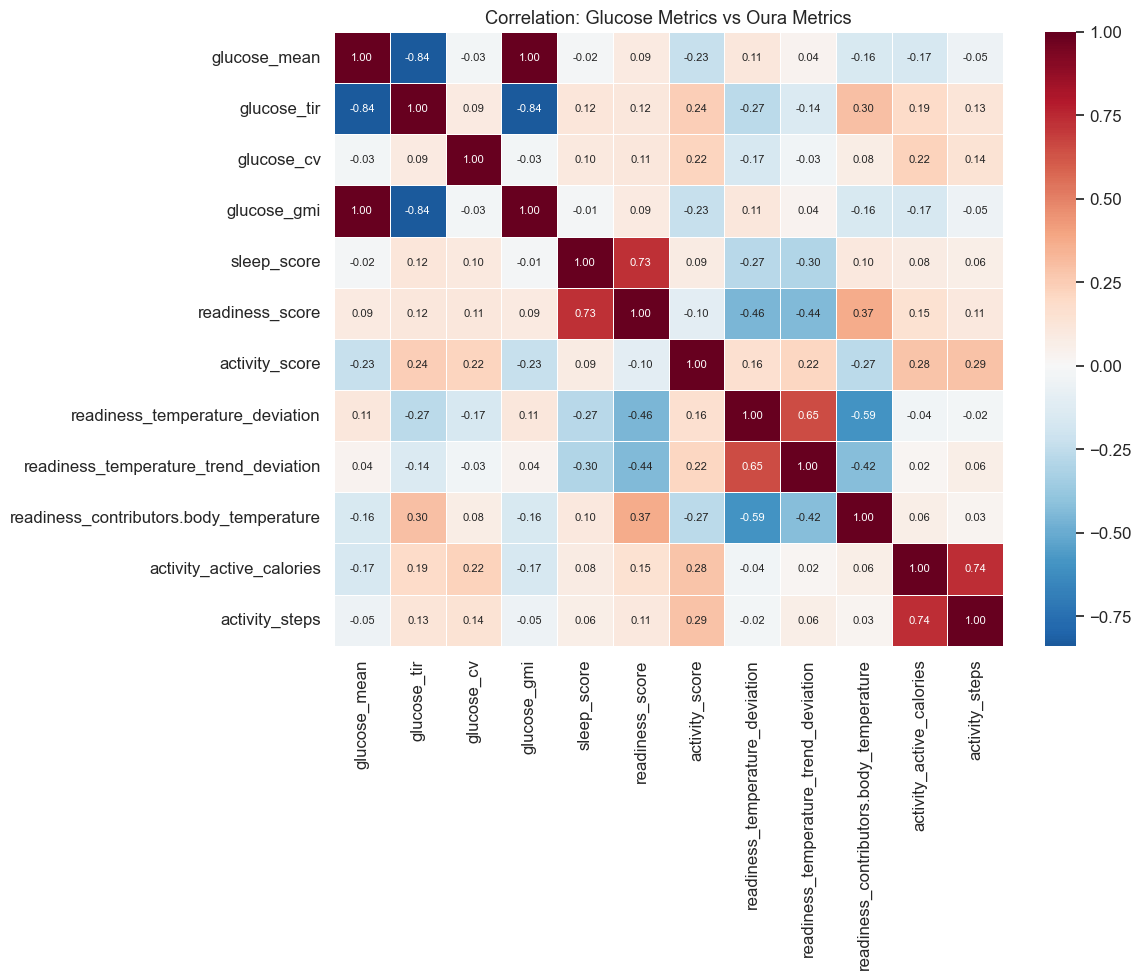

In [10]:
if has_oura:
    glucose_cols = ['glucose_mean', 'glucose_tir', 'glucose_cv', 'glucose_gmi']
    score_cols   = [c for c in merged.columns if c.endswith('_score')]
    extra_cols   = [c for c in merged.columns
                    if any(k in c for k in ['steps', 'active_calories', 'temperature'])]

    heat_cols = [c for c in glucose_cols + score_cols + extra_cols if c in merged.columns]
    corr = merged[heat_cols].corr()

    fig, ax = plt.subplots(figsize=(max(8, len(heat_cols)), max(6, len(heat_cols) - 2)))
    sns.heatmap(corr, annot=True, fmt='.2f', center=0, cmap='RdBu_r',
                linewidths=0.5, ax=ax, annot_kws={'size': 8})
    ax.set_title('Correlation: Glucose Metrics vs Oura Metrics')
    plt.tight_layout()
    plt.show()
else:
    # Glucose-only correlation
    glucose_cols = ['glucose_mean', 'glucose_std', 'glucose_tir', 'glucose_cv', 'glucose_gmi']
    corr = daily[glucose_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(corr, annot=True, fmt='.2f', center=0, cmap='RdBu_r', ax=ax)
    ax.set_title('Glucose Metric Correlations')
    plt.tight_layout()
    plt.show()

## 6. Summary Statistics

In [11]:
print('=== Overall Glucose Summary ===')
print(f'  All-time mean glucose : {daily["glucose_mean"].mean():.1f} mg/dL')
print(f'  Mean TIR              : {daily["glucose_tir"].mean()*100:.1f}%')
print(f'  Mean GMI              : {daily["glucose_gmi"].mean():.2f}%')
print(f'  Mean CV               : {daily["glucose_cv"].mean():.3f}')
print()

# Last 90 days
recent = daily[daily['date'] >= daily['date'].max() - pd.Timedelta('90D')]
print('=== Last 90 Days ===')
print(f'  Mean glucose : {recent["glucose_mean"].mean():.1f} mg/dL')
print(f'  Mean TIR     : {recent["glucose_tir"].mean()*100:.1f}%')
print(f'  Mean GMI     : {recent["glucose_gmi"].mean():.2f}%')

=== Overall Glucose Summary ===
  All-time mean glucose : 167.5 mg/dL
  Mean TIR              : 62.9%
  Mean GMI              : 7.32%
  Mean CV               : 0.284

=== Last 90 Days ===
  Mean glucose : 160.7 mg/dL
  Mean TIR     : 62.0%
  Mean GMI     : 7.15%
